# 01 – Exploratory Data Analysis (EDA)

This notebook explores the ACIS auto insurance dataset. It focuses on:

- Understanding the structure and quality of the data
- Creating basic risk metrics (loss ratio, margin, claim flag)
- Visualising distributions and key risk drivers


In [1]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features.build_features import add_core_features

pd.set_option("display.max_columns", 100)
sns.set(style="whitegrid")


## 1. Load the raw dataset

In [2]:
DATA_PATH = os.path.join("..", "data", "raw", "MachineLearningRating_v3.txt")

df = pd.read_csv(
    DATA_PATH,
    sep="|",            # pipe separator
    engine="python",
    on_bad_lines="skip"
)

df.head()


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,Province,PostalCode,MainCrestaZone,SubCrestaZone,ItemType,mmcode,VehicleType,RegistrationYear,make,Model,Cylinders,cubiccapacity,kilowatts,bodytype,NumberOfDoors,VehicleIntroDate,CustomValueEstimate,AlarmImmobiliser,TrackingDevice,CapitalOutstanding,NewVehicle,WrittenOff,Rebuilt,Converted,CrossBorder,NumberOfVehiclesInFleet,SumInsured,TermFrequency,CalculatedPremiumPerTerm,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,119300.00,Monthly,584.6468,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,119300.00,Monthly,584.6468,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


##3. Check columns

In [4]:
# Inspect all column names in the dataset
df.columns.tolist()


['UnderwrittenCoverID',
 'PolicyID',
 'TransactionMonth',
 'IsVATRegistered',
 'Citizenship',
 'LegalType',
 'Title',
 'Language',
 'Bank',
 'AccountType',
 'MaritalStatus',
 'Gender',
 'Country',
 'Province',
 'PostalCode',
 'MainCrestaZone',
 'SubCrestaZone',
 'ItemType',
 'mmcode',
 'VehicleType',
 'RegistrationYear',
 'make',
 'Model',
 'Cylinders',
 'cubiccapacity',
 'kilowatts',
 'bodytype',
 'NumberOfDoors',
 'VehicleIntroDate',
 'CustomValueEstimate',
 'AlarmImmobiliser',
 'TrackingDevice',
 'CapitalOutstanding',
 'NewVehicle',
 'WrittenOff',
 'Rebuilt',
 'Converted',
 'CrossBorder',
 'NumberOfVehiclesInFleet',
 'SumInsured',
 'TermFrequency',
 'CalculatedPremiumPerTerm',
 'ExcessSelected',
 'CoverCategory',
 'CoverType',
 'CoverGroup',
 'Section',
 'Product',
 'StatutoryClass',
 'StatutoryRiskType',
 'TotalPremium',
 'TotalClaims']

## 4. Basic structure and summary

In [6]:
df.info()

# Summary stats for first 20 columns
df.describe(include="all").transpose().head(20)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  object 
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  object 
 5   LegalType                 1000098 non-null  object 
 6   Title                     1000098 non-null  object 
 7   Language                  1000098 non-null  object 
 8   Bank                      854137 non-null   object 
 9   AccountType               959866 non-null   object 
 10  MaritalStatus             991839 non-null   object 
 11  Gender                    990562 non-null   object 
 12  Country                   1000098 non-null  object 
 13  Province                  1

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
UnderwrittenCoverID,1000098.0,NaN,NaN,NaN,104817.546075,63293.708455,1.0,55143.0,94083.0,139190.0,301175.0
PolicyID,1000098.0,NaN,NaN,NaN,7956.68245,5290.03851,14.0,4500.0,7071.0,11077.0,23246.0
TransactionMonth,1000098,23,2015-08-01 00:00:00,106747,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IsVATRegistered,1000098,2,False,995075,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Citizenship,1000098,4,,895210,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LegalType,1000098,6,Individual,911929,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Title,1000098,5,Mr,933555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Language,1000098,1,English,1000098,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bank,854137,11,First National Bank,260811,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AccountType,959866,3,Current account,597938,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Add core risk features

In [7]:
df = add_core_features(df)

df[["TotalPremium", "TotalClaims", "LossRatio", "Margin", "HasClaim"]].head()


,TotalPremium,TotalClaims,LossRatio,Margin,HasClaim
0,21.929825,0.0,0.0,21.929825,0
1,21.929825,0.0,0.0,21.929825,0
2,0.000000,0.0,<NA>,0.000000,0
3,512.848070,0.0,0.0,512.848070,0
4,0.000000,0.0,<NA>,0.000000,0


## 7. Missing values overview

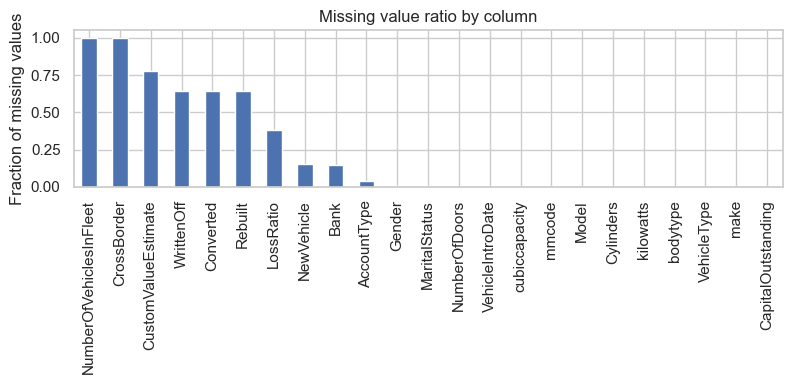

In [8]:
# Fraction of missing values per column
missing = df.isna().mean().sort_values(ascending=False)
missing[missing > 0].head(20)


# Plot missing values
plt.figure(figsize=(8, 4))
missing[missing > 0].plot(kind="bar")
plt.title("Missing value ratio by column")
plt.ylabel("Fraction of missing values")
plt.tight_layout()
plt.show()


## 8. Overall portfolio metrics

In [9]:
if {"TotalPremium", "TotalClaims"}.issubset(df.columns):
    total_premium = df["TotalPremium"].sum()
    total_claims = df["TotalClaims"].sum()
    overall_loss_ratio = total_claims / total_premium if total_premium > 0 else np.nan

    print(f"Total premium: {total_premium:,.0f}")
    print(f"Total claims:  {total_claims:,.0f}")
    print(f"Overall loss ratio: {overall_loss_ratio:.3f}")
else:
    print("Columns 'TotalPremium' and/or 'TotalClaims' not found in the dataset.")


Total premium: 61,911,563
Total claims:  64,867,546
Overall loss ratio: 1.048


## 8 Group by Province / VehicleType / Gender

In [10]:
group_cols = ["Province", "VehicleType", "Gender"]

for col in group_cols:
    if col in df.columns:
        summary = (
            df.groupby(col)
            .agg(
                policies=("PolicyID", "nunique"),
                total_premium=("TotalPremium", "sum"),
                total_claims=("TotalClaims", "sum"),
                loss_ratio=("LossRatio", "mean"),
                claim_frequency=("HasClaim", "mean"),
            )
            .sort_values("loss_ratio", ascending=False)
        )
        print(f"\n=== {col} ===")
        display(summary.head(10))
    else:
        print(f"\nColumn '{col}' not found in the dataset.")
  


=== Province ===


,policies,total_premium,total_claims,loss_ratio,claim_frequency
Province,,,,,
Gauteng,2578,2.405377e+07,2.939415e+07,0.025231,0.003356
KwaZulu-Natal,1370,1.320908e+07,1.430138e+07,0.019768,0.002845
Mpumalanga,382,2.836292e+06,2.044675e+06,0.01963,0.002428
North West,1117,7.490508e+06,5.920250e+06,0.018301,0.002436
Limpopo,181,1.537324e+06,1.016477e+06,0.017956,0.002698
Western Cape,947,9.806559e+06,1.038977e+07,0.017505,0.002166
Eastern Cape,319,2.140104e+06,1.356427e+06,0.01178,0.001648
Northern Cape,55,3.165581e+05,8.949051e+04,0.01098,0.001254
Free State,54,5.213632e+05,3.549223e+05,0.007586,0.001358



=== VehicleType ===


,policies,total_premium,total_claims,loss_ratio,claim_frequency
VehicleType,,,,,
Medium Commercial,457,3.922746e+06,4.119867e+06,0.022466,0.002927
Heavy Commercial,72,4.609479e+05,7.504746e+05,0.021348,0.002837
Passenger Vehicle,6695,5.664202e+07,5.937207e+07,0.020749,0.002771
Light Commercial,39,2.604975e+05,6.045250e+04,0.015302,0.002053
Bus,6,5.824474e+04,7.996535e+03,0.0,0.001504



=== Gender ===


,policies,total_premium,total_claims,loss_ratio,claim_frequency
Gender,,,,,
Male,232,1.580143e+06,1.396704e+06,0.021385,0.002195
Not specified,6601,5.920275e+07,6.271410e+07,0.020895,0.002833
Female,35,3.044806e+05,2.502461e+05,0.017876,0.002073


## 9 Time trends (TransactionMonth)

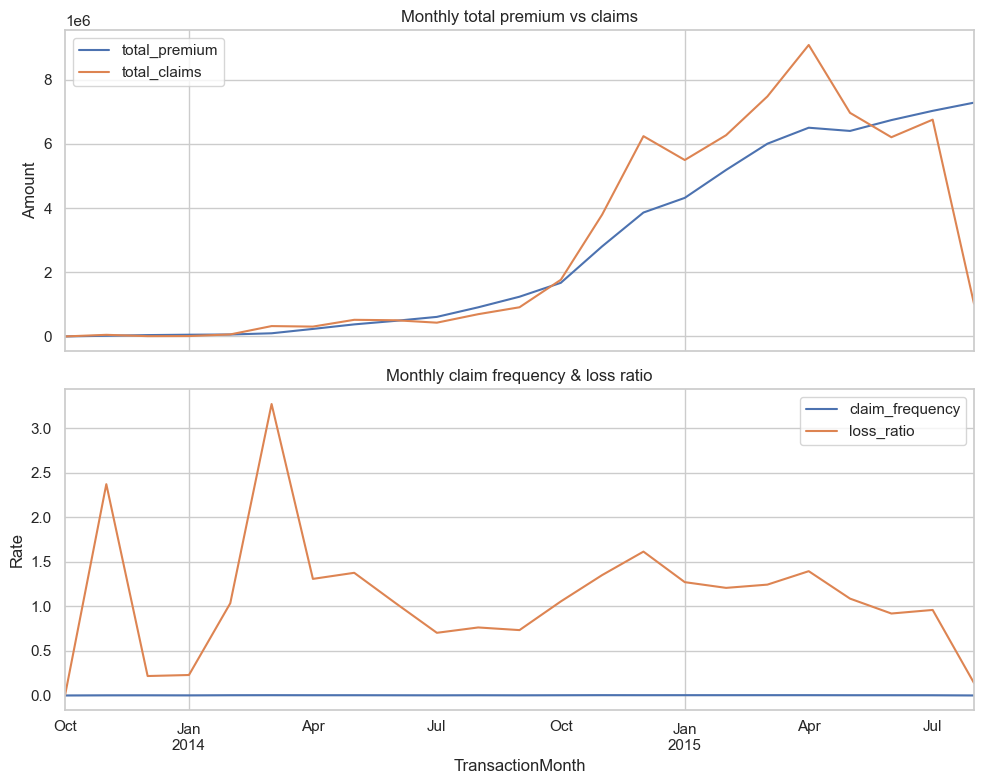

In [11]:
if "TransactionMonth" in df.columns:
    # Ensure it's datetime
    df["TransactionMonth"] = pd.to_datetime(df["TransactionMonth"])

    monthly = (
        df.groupby("TransactionMonth")
        .agg(
            total_premium=("TotalPremium", "sum"),
            total_claims=("TotalClaims", "sum"),
            claim_frequency=("HasClaim", "mean"),
        )
        .sort_index()
    )
    monthly["loss_ratio"] = monthly["total_claims"] / monthly["total_premium"]

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    monthly[["total_premium", "total_claims"]].plot(ax=axes[0])
    axes[0].set_title("Monthly total premium vs claims")
    axes[0].set_ylabel("Amount")

    monthly[["claim_frequency", "loss_ratio"]].plot(ax=axes[1])
    axes[1].set_title("Monthly claim frequency & loss ratio")
    axes[1].set_ylabel("Rate")

    plt.tight_layout()
    plt.show()
else:
    print("Column 'TransactionMonth' not found in dataset.")


## 10 Creative plot: loss ratio by province

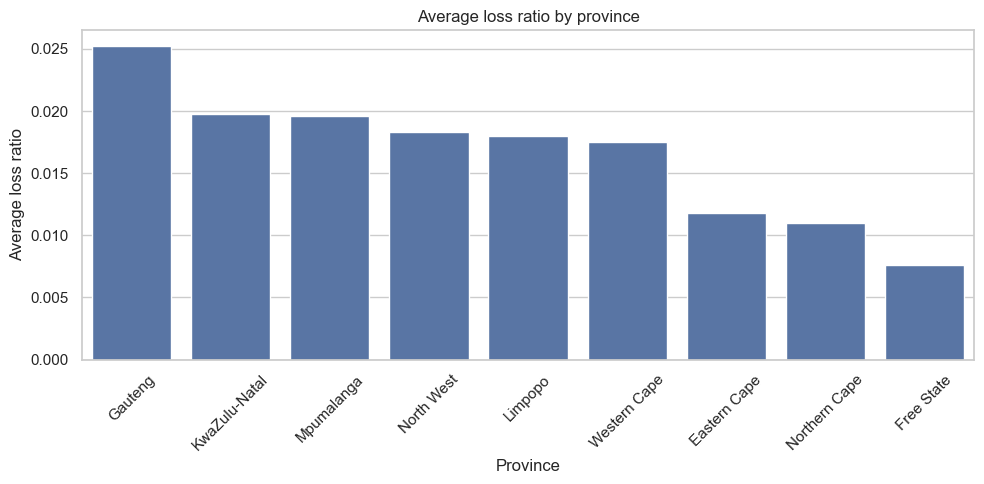

In [12]:
if "Province" in df.columns and "LossRatio" in df.columns:
    prov = (
        df.groupby("Province")
        .agg(
            loss_ratio=("LossRatio", "mean"),
            claim_frequency=("HasClaim", "mean"),
            policies=("PolicyID", "nunique"),
        )
        .sort_values("loss_ratio", ascending=False)
    )

    plt.figure(figsize=(10, 5))
    sns.barplot(x=prov.index, y=prov["loss_ratio"])
    plt.xticks(rotation=45)
    plt.ylabel("Average loss ratio")
    plt.title("Average loss ratio by province")
    plt.tight_layout()
    plt.show()
else:
    print("Required columns not found to plot loss ratio by province.")
